In [1]:
# ===================================================================================
# 다변량(멀티) 시계열 기반 설비 고장 조기 예측 + 품질 원인 분류 멀티태스크 모델
#
# 1. 제조 설비 센서 데이터를 시뮬레이션
# 2. 시계열 윈도우를 생성
# 3. 1D CNN + BiLSTM + Attension 기반 멀티 태스크 모델 생성 및 학습
# 4. 고장 여부와 원인 분류 수행
# 5. 모델, 스케일러, 학습이력, 예측 결과 저장 및 수행
# 6. 신규 데이터 기반 예측 결과 및 시각화 수행

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM, GlobalAveragePooling1D
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.models import Model

# 학습 제어 콜백을 불러온다.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)


In [2]:
# ------------------------------
# 1. 데이터 설정 
# ------------------------------

# 전체 시뮬레이션 샘플 수를 정의
n_sequences = 4000

# 한 시퀀스의 길이를 정의
seq_len = 60

# 센서 개수를 정의
n_features = 6

# 품질 원인 클래스 수를 정의
n_cause_classes = 4

# 센서 이름을 정의
feature_names = ["temperature", "pressure", "vibration", "current", "speed", "thickness"]

In [3]:
# ------------------------------
# 2. 시계열 데이터 생성 함수 정의
# ------------------------------

# 하나의 시퀀스를 생성하는 함수를 정의
def generate_sequence(seq_len, mode, cause_class):
    # 시간축을 0부터 1까지 균등 분할하여 생성
    t = np.linspace(0, 1, seq_len)

    # temperature 기본 패턴을 생성
    temperature = 50 + 3 * np.sin(2 * np.pi * 2 * t) + np.random.normal(0, 0.6, seq_len)

    # pressure 기본 패턴을 생성
    pressure = 100 + 5 * np.cos(2 * np.pi * 1.5 * t) + np.random.normal(0, 0.8, seq_len)

    # vibration 기본 패턴을 생성
    vibration = 10 + 0.5 * np.sin(2 * np.pi * 6 * t) + np.random.normal(0, 0.3, seq_len)

    # current 기본 패턴을 생성
    current = 20 + 1.2 * np.sin(2 * np.pi * 3 * t) + np.random.normal(0, 0.4, seq_len)

    # speed 기본 패턴을 생성
    speed = 1500 + 25 * np.cos(2 * np.pi * 2.5 * t) + np.random.normal(0, 5, seq_len)

    # thickness 기본 패턴을 생성
    thickness = 1.20 + 0.02 * np.sin(2 * np.pi * 1.2 * t) + np.random.normal(0, 0.01, seq_len)

    # 정상 모드가 아니라면 이상 패턴을 삽입
    if mode == "fault":
        # 원인 클래스 0이면 온도와 전류 상승 패턴을 삽입
        if cause_class == 0:
            temperature += np.linspace(0, 10, seq_len)
            current += np.linspace(0, 8, seq_len)

        # 원인 클래스 1이면 압력 급상승과 두께 편차를 삽입
        elif cause_class == 1:
            pressure += np.linspace(0, 18, seq_len)
            thickness += np.linspace(0, 0.10, seq_len)

        # 원인 클래스 2이면 진동 증가와 속도 저하를 삽입
        elif cause_class == 2:
            vibration += np.linspace(0, 6, seq_len)
            speed -= np.linspace(0, 160, seq_len)

        # 원인 클래스 3이면 복합 이상 패턴을 삽입
        elif cause_class == 3:
            temperature += np.linspace(0, 6, seq_len)
            pressure += np.linspace(0, 10, seq_len)
            vibration += np.linspace(0, 3, seq_len)
            current += np.linspace(0, 4, seq_len)

    # 생성된 각 센서를 열 방향으로 쌓아 하나의 2차원 시퀀스로 만듬
    sequence = np.column_stack([temperature, pressure, vibration, current, speed, thickness])

    # 생성된 시퀀스를 반환
    return sequence

In [4]:
# ------------------------------
# 3. 전체 데이터셋 생성
# ------------------------------

# 입력 시퀀스를 저장할 리스트를 생성
X_list = []

# 고장 여부 라벨을 저장할 리스트를 생성
y_fault_list = []

# 원인 클래스 라벨을 저장할 리스트를 생성
y_cause_list = []

# 전체 샘플 수만큼 반복
for i in range(n_sequences):
    mode = np.random.choice(["normal", "fault"], p=[0.7, 0.3])  # 70%는 정상, 30%는 이상이 되도록 랜덤하게 모드를 선택

    if mode == "normal":
        cause_class = 0
        
    # 이상일 경우 1~3 중 하나를 원인 클래스로 사용
    else:
        cause_class = np.random.choice([1, 2, 3])

    # 시퀀스를 생성
    seq = generate_sequence(seq_len=seq_len, mode=mode, cause_class=cause_class)

    # 입력 리스트에 시퀀스를 추가
    X_list.append(seq)

    # 고장 여부 라벨을 추가, 정상은 0, 이상은 1
    y_fault_list.append(0 if mode == "normal" else 1)

    # 원인 클래스 라벨을 추가
    y_cause_list.append(cause_class)

# 입력 리스트를 numpy 배열로 변환
X = np.array(X_list)

# 고장 여부 라벨을 numpy 배열로 변환
y_fault = np.array(y_fault_list)

# 원인 클래스 라벨을 numpy 배열로 변환
y_cause = np.array(y_cause_list)

# 고장 여부 라벨 shape를 출력
print("y_fault shape:", y_fault.shape)
# 원인 라벨 shape를 출력
print("y_cause shape:", y_cause.shape)
# 고장 여부 클래스 분포를 출력
print("Fault label distribution:\n", pd.Series(y_fault).value_counts().sort_index())
# 원인 클래스 분포를 출력
print("Cause label distribution:\n", pd.Series(y_cause).value_counts().sort_index())

y_fault shape: (4000,)
y_cause shape: (4000,)
Fault label distribution:
 0    2800
1    1200
Name: count, dtype: int64
Cause label distribution:
 0    2800
1     395
2     387
3     418
Name: count, dtype: int64


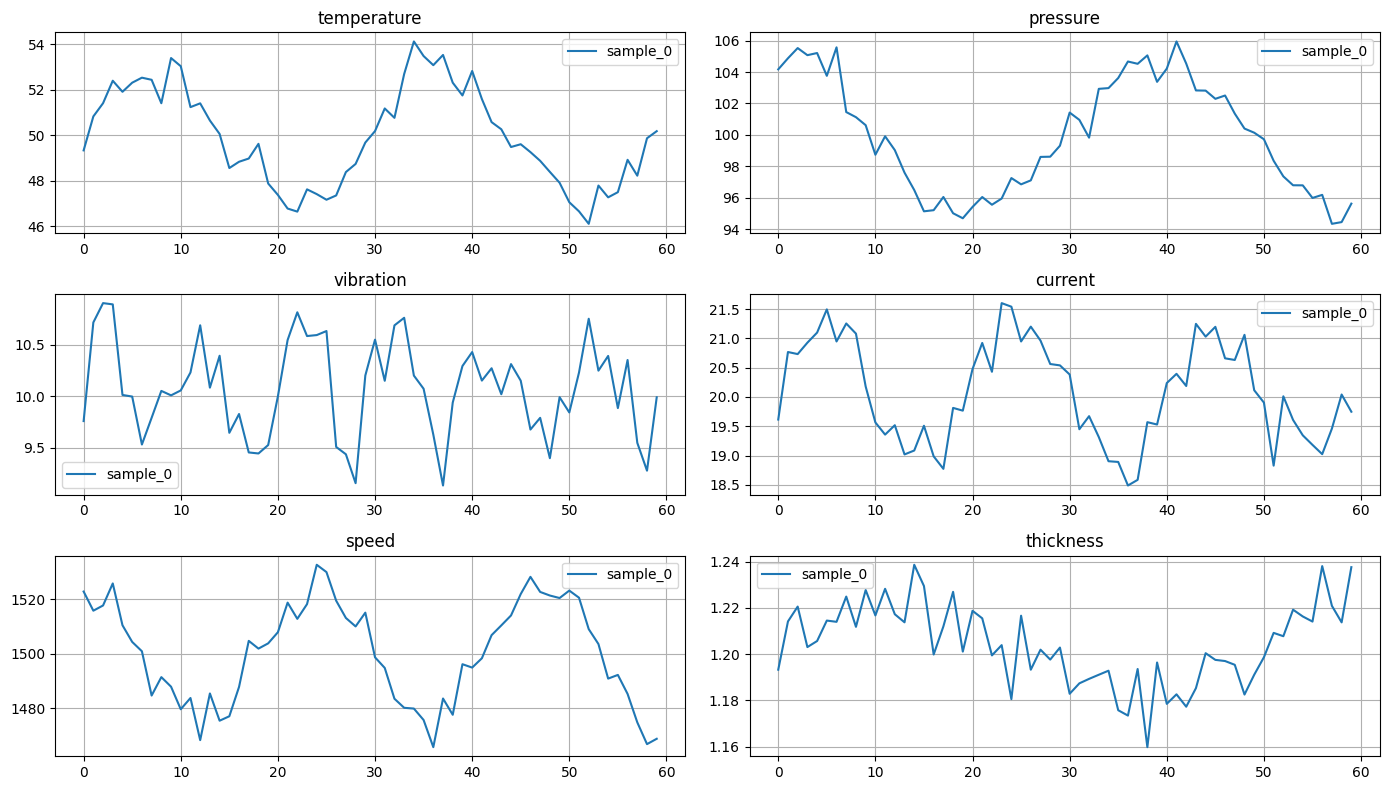

In [5]:
# ------------------------------
# 4. 시퀀스 데이터 시각화
# ------------------------------

plt.figure(figsize=(14, 8))

# 각 센서별로 subplot을 생성하기 위해 반복
for idx in range(n_features):
    # 3행 2열 구조의 subplot을 생성
    plt.subplot(3, 2, idx + 1)

    # 첫 번째 정상 샘플의 해당 센서 시퀀스를 표시
    plt.plot(X[0, :, idx], label="sample_0")
    plt.title(feature_names[idx])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# ------------------------------
# 5. 학습 / 검증 / 테스트 데이터 분리
# ------------------------------

# 학습용과 임시용으로 데이터를 분리
X_train, X_temp, y_fault_train, y_fault_temp, y_cause_train, y_cause_temp = train_test_split(
    X, y_fault, y_cause, test_size=0.2, random_state=42, stratify=y_fault
)

# 임시 데이터를 검증용과 테스트용으로 분리
X_val, X_test, y_fault_val, y_fault_test, y_cause_val, y_cause_test = train_test_split(
    X_temp, y_fault_temp, y_cause_temp, test_size=0.5, random_state=42, stratify=y_fault_temp
)

# 분리 결과 shape를 출력
print("Train:", X_train.shape, y_fault_train.shape, y_cause_train.shape)
print("Val  :", X_val.shape, y_fault_val.shape, y_cause_val.shape)
print("Test :", X_test.shape, y_fault_test.shape, y_cause_test.shape)

Train: (3200, 60, 6) (3200,) (3200,)
Val  : (400, 60, 6) (400,) (400,)
Test : (400, 60, 6) (400,) (400,)


In [7]:
# ------------------------------
# 6. 시계열 데이터 정규화
# ------------------------------

# 시계열 데이터 : (samples, timestamps, features)
# 시계열 데이터는 3차원 형태이므로 스케일러 적용을 위해 2차원으로 펼쳐야 함
# 먼저 StandardScaler 객체를 생성
scaler = StandardScaler()

# 학습 데이터를 (샘플*시점, 센서수) 형태로 reshape
X_train_2d = X_train.reshape(-1, n_features)

# 검증 데이터를 2차원으로 reshape
X_val_2d = X_val.reshape(-1, n_features)

# 테스트 데이터를 2차원으로 reshape
X_test_2d = X_test.reshape(-1, n_features)

# 학습 데이터 기준으로 스케일러를 학습하고 변환
X_train_scaled_2d = scaler.fit_transform(X_train_2d)

# 검증 데이터를 동일 스케일러로 변환
X_val_scaled_2d = scaler.transform(X_val_2d)

# 테스트 데이터를 동일 스케일러로 변환
X_test_scaled_2d = scaler.transform(X_test_2d)

# 다시 원래의 3차원 시계열 형태로 복원
X_train_scaled = X_train_scaled_2d.reshape(-1, seq_len, n_features)

# 검증 데이터도 3차원으로 복원
X_val_scaled = X_val_scaled_2d.reshape(-1, seq_len, n_features)

# 테스트 데이터도 3차원으로 복원
X_test_scaled = X_test_scaled_2d.reshape(-1, seq_len, n_features)

In [8]:
# ------------------------------
# 7. 고급 멀티태스크 모델 구성
#    구조:
#    입력 -> Conv1D -> Pooling -> BiLSTM -> Self-Attention -> Dense
#         -> 출력1: fault_output (이진분류)
#         -> 출력2: cause_output (멀티클래스 분류)
# ------------------------------

# 입력 텐서 레이어 정의
inputs = Input(shape=(seq_len, n_features), name="sensor_input")

# 첫 번째 1D CNN 레이어를 적용해서 기본적인 패턴 추출
x = Conv1D(filters=64, kernel_size=3, padding="same", activation="relu", name="conv1")(inputs)
x = Dropout(0.2, name="dropout_conv1")(x)    # 과적합 방지를 위해 드롭아웃 적용 (20%)

# 두 번째 1D CNN 레이어를 적용해서 조금 더 복잡 한 패턴 추출
x = Conv1D(filters=64, kernel_size=3, padding="same", activation="relu", name="conv2")(x)
# 풀링을 적용해서 시퀀스 길이를 축소하고 핵심 특징만 남김
x = MaxPooling1D(pool_size=2, name="maxpool1")(x)


# 양방향 LSTM을 적용해서 과거와 현재 미래의 연결성을 반영
x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm")(x)


# Self-Attension 적용 전 정규화 수행
attn_input = LayerNormalization(name="attn_norm1")(x)

# 멀티헤드 어텐션을 적용해서 중요한 시점 간 관계를 학습
'''
MultiHeadAttention : 여러 개의 Attension을 동시에 적용해서 다양한 관점의 관계를 학습
--> 동시 attension 병렬 처리 (속도 향상)
--> 다양한 패턴 학습 (표현력 향상)
'''
attn_output = MultiHeadAttention(num_heads=4, 
                                 key_dim=32, 
                                 name="multihead_attention")(attn_input, attn_input)

# 잔차 연결을 통해 원본 특징과 어텐션 결과 더해줌
x = Add(name="attn_residual")([x, attn_output])

# 다시 정규화 수행
x = LayerNormalization(name="attn_norm2")(x)

# 시계열의 전체 정보를 요약하기 위한 GlobalAveragePooling1D 적용
x = GlobalAveragePooling1D(name="global_avg_pool")(x)

# 공통 표현 학습용 Dense 레이어 추가
shared = Dense(128, activation="relu", name="shared_dense1")(x)
shared = Dropout(0.3, name="shared_dropout1")(shared)

# Dense 레이어 다시 추가 
shared = Dense(64, activation="relu", name="shared_dense2")(shared)
shared = Dropout(0.2, name="shared_dropout2")(shared)

# 고장 여부 예측용 분류기 Densce 레이어 정의
fault_branch = Dense(32, activation="relu", name="fault_dense")(shared)
# 고장 여부 이진분류를 위한 출력층 정의
fault_output = Dense(1, activation="sigmoid", name="fault_output")(fault_branch)

# 원인 분류용 분류기 Dense 레이어 정의
cause_branch = Dense(32, activation="relu", name="cause_dense")(shared)
# 원인 멀티클래스 분류 출력증 정의
cause_output = Dense(n_cause_classes, activation="softmax", name="cause_output")(cause_branch)

# 멀티출력 모델 생성
model = Model(inputs=inputs, outputs=[fault_output, cause_output], 
              name="predictive_maintenance_multitask_model")

# 모델 요약을 출력
model.summary()







Model: "predictive_maintenance_multitask_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sensor_input (InputLayer)     │ (None, 60, 6)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1 (Conv1D)                │ (None, 60, 64)            │           1,216 │ sensor_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_conv1 (Dropout)       │ (None, 60, 64)            │               0 │ conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2 (Conv1D)                │ (None, 60, 64)            │          12,352 │ dropout_conv1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ maxpool1 (MaxPooling1D)       │ (None, 30, 64)            │               0 │ conv2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm (Bidirectional)        │ (None, 30, 128)           │          66,048 │ maxpool1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attn_norm1                    │ (None, 30, 128)           │             256 │ bilstm[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multihead_attention           │ (None, 30, 128)           │          66,048 │ attn_norm1[0][0],          │
│ (MultiHeadAttention)          │                           │                 │ attn_norm1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attn_residual (Add)           │ (None, 30, 128)           │               0 │ bilstm[0][0],              │
│                               │                           │                 │ multihead_attention[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attn_norm2                    │ (None, 30, 128)           │             256 │ attn_residual[0][0]        │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_avg_pool               │ (None, 128)               │               0 │ attn_norm2[0][0]           │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dense1 (Dense)         │ (None, 128)               │          16,512 │ global_avg_pool[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout1 (Dropout)     │ (None, 128)               │               0 │ shared_dense1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dense2 (Dense)         │ (None, 64)                │           8,256 │ shared_dropout1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout2 (Dropout)     │ (None, 64)                │               

 Total params: 175,269 (684.64 KB)

 Trainable params: 175,269 (684.64 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ------------------------------
# 8. 모델 컴파일
# ------------------------------
# 멀티태스크 손실함수와 평가지표를 지정하여 모델을 컴파일한다.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "fault_output": "binary_crossentropy",
        "cause_output": "sparse_categorical_crossentropy"
    },
    loss_weights={
        "fault_output": 1.0,
        "cause_output": 1.0
    },
    metrics={
        "fault_output": ["accuracy"],
        "cause_output": ["accuracy"]
    }
)


In [10]:
# ------------------------------
# 9. 콜백 설정
# ------------------------------
# 검증 손실이 개선되 않으면 학습을 조기 종료하는 콜백정의
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 검증 손실이 정체시, 학습률을 감소시키는 콜백정의
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# 가장 좋은 모델을 파일로 저장하는 콜백 정의
checkpoint = ModelCheckpoint(
    filepath="best_multitask_model.keras",
    monitor="val_loss",
    save_best_only=True
)


In [ ]:
# ------------------------------
# 10. 모델 학습
# ------------------------------

# 모델을 학습하고 학습 이력을 history 객체에 저장
history = model.fit(
    X_train_scaled,
    {
        "fault_output": y_fault_train,
        "cause_output": y_cause_train
    },
    validation_data=(
        X_val_scaled,
        {
            "fault_output": y_fault_val,
            "cause_output": y_cause_val
        }
    ),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - cause_output_accuracy: 0.9172 - cause_output_loss: 0.2115 - fault_output_accuracy: 0.9622 - fault_output_loss: 0.1056 - loss: 0.3170 - val_cause_output_accuracy: 1.0000 - val_cause_output_loss: 8.8014e-05 - val_fault_output_accuracy: 1.0000 - val_fault_output_loss: 1.5772e-04 - val_loss: 2.4563e-04 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - cause_output_accuracy: 1.0000 - cause_output_loss: 0.0015 - fault_output_accuracy: 1.0000 - fault_output_loss: 7.6435e-04 - loss: 0.0022 - val_cause_output_accuracy: 1.0000 - val_cause_output_loss: 1.2521e-05 - val_fault_output_accuracy: 1.0000 - val_fault_output_loss: 3.1136e-05 - val_loss: 4.3794e-05 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - cause_output_accuracy: 1.0000 - cause_output_loss: 8.0737e-04 - fault_output_accuracy: 1.0000 - fault_output_loss: 4.3306e-04 - loss: 0.0012 - val_cause_output_accuracy: 1.0000 - val_cause_